#🔑 Part 0: Google Cloud Authentication
Colab requires us to verify our Google account before it allows us to use the high-speed gcloud pipeline to download the dataset. Run this cell and click through the standard Google permissions popup.

In [2]:
from google.colab import auth
auth.authenticate_user()
print("✅ Authenticated successfully! You can now run the data download cell.")

✅ Authenticated successfully! You can now run the data download cell.


#🌩️ Part 1: Pulling Satellite Data from Google Cloud
We need to bypass standard slow downloads and rip the gold-standard Sen1Floods11 hand-labeled dataset straight from Google Cloud Storage into our Colab instance.

In [3]:
# Create the exact directory structure
!mkdir -p /content/sen1floods11/HandLabeled

# Use the fast gcloud storage command to pull the folder recursively
!gcloud storage cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/* /content/sen1floods11/HandLabeled/

Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_195474_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_195474_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_23014_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_23014_JRCWaterHand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_233925_JRCWaterHand.tif to file:///content/sen1floods11/HandLabeled/JRCWaterHand/Bolivia_233925_JRCWaterHand.tif
Copying gs://sen1floods11/v

🛠️ Part 2: Installing Dependencies
Colab has PyTorch pre-installed, but we need rasterio for reading .tif satellite files and segmentation-models-pytorch to easily build our U-Net.

In [4]:
!pip install segmentation-models-pytorch rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


🧠 Part 3: Environment Setup & Imports
Importing our core libraries and ensuring PyTorch is hooked up to the free T4 GPU so our model trains in minutes instead of days.

In [5]:
import os
import glob
import torch
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import torch.nn as nn
import torch.optim as optim

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Currently running on device: {device}")

🔥 Currently running on device: cuda


📂 Part 4: Building the SAR Dataset Loader
Sentinel-1 SAR radar imagery uses two polarization bands (VV and VH). This custom dataset class pairs those 2-channel images with their corresponding binary flood masks (1 = Flood, 0 = Dry Land).

In [6]:
class Sen1FloodsDataset(Dataset):
    def __init__(self, data_dir):
        # 1. Recursively search through all subfolders for the radar images
        self.image_paths = sorted(glob.glob(os.path.join(data_dir, '**', '*_S1Hand.tif'), recursive=True))

        # 2. The masks are in a different folder with a different suffix.
        # We replace both the folder name ('S1Hand' -> 'LabelHand') and the file suffix.
        self.mask_paths = [path.replace('S1Hand', 'LabelHand') for path in self.image_paths]

        print(f"✅ Found {len(self.image_paths)} image/mask pairs.")

        # A quick safety check just in case the download failed entirely
        if len(self.image_paths) == 0:
            print("🚨 ERROR: Still 0 files found. Let's check what is actually in the folder:")
            os.system(f"ls -R {data_dir} | head -n 20")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Read SAR Image (2 bands: VV and VH)
        with rasterio.open(self.image_paths[idx]) as src:
            image = src.read()
            image = np.nan_to_num(image)
            image = np.clip(image, -30, 0)
            image = (image + 30) / 30.0

        # 2. Read Ground Truth Mask
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1)
            mask = np.where(mask == 1, 1.0, 0.0)

        # 3. Convert to PyTorch Tensors
        image_tensor = torch.tensor(image, dtype=torch.float32)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor

# Initialize the dataset and loader
from torch.utils.data import random_split

# Initialize the dataset
data_directory = '/content/sen1floods11/HandLabeled/'
full_dataset = Sen1FloodsDataset(data_directory)

# Split into 80% training and 20% validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

✅ Found 446 image/mask pairs.
Training samples: 356
Validation samples: 90


🏗️ Part 5 (Upgraded): U-Net with Weighted Loss
We are using a U-Net with a ResNet34 backbone. To combat "Class Imbalance" (where 95% of the map is dry land), we are adding a pos_weight to our Loss Function. This forces the model to pay 10x more attention to the rare flood pixels, preventing it from just lazily guessing "Dry Land" everywhere.

In [7]:
# 1. Initialize the Segmentation Model
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=2,
    classes=1,
)

model = model.to(device)

# 2. Add the "Bounty" (Positive Weight)
# This tells the model: Missing a flood pixel is 10x worse than missing a dry pixel
weight_multiplier = torch.tensor([10.0]).to(device)

# 3. Initialize the Weighted Loss Function and Optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=weight_multiplier)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
print("⚖️ Model and Weighted Loss Function initialized successfully!")

⚖️ Model and Weighted Loss Function initialized successfully!


🚀 Part 6 (Upgraded): Advanced Training Loop
We are bumping the training up to 30 epochs. We are also introducing a ReduceLROnPlateau scheduler. If the model stops improving (e.g., gets stuck looking at the black border), the scheduler dynamically reduces the learning rate to help the model zero in on the finer details of the actual floodwater.

In [9]:
# 1. Reset the optimizer to clear out its old memory
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 2. Add the Scheduler (Removed 'verbose=True' to fix PyTorch TypeError)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
def iou_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_score(pred, target, threshold=0.5):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
def train_model_advanced(model, train_loader, val_loader, epochs=30):
    print("🚀 Initiating deep-dive training sequence...")

    best_loss = float('inf')

    for epoch in range(epochs):

        # ================= TRAIN =================
        model.train()
        train_loss = 0
        train_iou = 0
        train_dice = 0

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_iou += iou_score(outputs, masks).item()
            train_dice += dice_score(outputs, masks).item()

        avg_train_loss = train_loss / len(train_loader)
        avg_train_iou = train_iou / len(train_loader)
        avg_train_dice = train_dice / len(train_loader)

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0
        val_iou = 0
        val_dice = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                val_iou += iou_score(outputs, masks).item()
                val_dice += dice_score(outputs, masks).item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)

        scheduler.step(avg_val_loss)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), "flood_unet_resnet34_best.pth")
            print("✅ Best model saved!")

        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Train IoU: {avg_train_iou:.4f} | "
            f"Train Dice: {avg_train_dice:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val IoU: {avg_val_iou:.4f} | "
            f"Val Dice: {avg_val_dice:.4f} | "
            f"LR: {current_lr:.6f}"
        )

# Execute the advanced training! Grab a coffee, this will take a few minutes.
train_model_advanced(model, train_loader, val_loader, epochs=30)

🚀 Initiating deep-dive training sequence...
✅ Best model saved!
Epoch 01/30 | Train Loss: 0.5134 | Train IoU: 0.3633 | Train Dice: 0.4936 | Val Loss: 0.5574 | Val IoU: 0.3759 | Val Dice: 0.5083 | LR: 0.000100
✅ Best model saved!
Epoch 02/30 | Train Loss: 0.4905 | Train IoU: 0.3638 | Train Dice: 0.4975 | Val Loss: 0.5518 | Val IoU: 0.4916 | Val Dice: 0.6219 | LR: 0.000100
Epoch 03/30 | Train Loss: 0.4709 | Train IoU: 0.3593 | Train Dice: 0.4914 | Val Loss: 0.5623 | Val IoU: 0.3450 | Val Dice: 0.4779 | LR: 0.000100
✅ Best model saved!
Epoch 04/30 | Train Loss: 0.5142 | Train IoU: 0.3533 | Train Dice: 0.4859 | Val Loss: 0.5211 | Val IoU: 0.4713 | Val Dice: 0.6013 | LR: 0.000100
✅ Best model saved!
Epoch 05/30 | Train Loss: 0.4940 | Train IoU: 0.3517 | Train Dice: 0.4846 | Val Loss: 0.5040 | Val IoU: 0.4558 | Val Dice: 0.5871 | LR: 0.000100
Epoch 06/30 | Train Loss: 0.4939 | Train IoU: 0.3475 | Train Dice: 0.4792 | Val Loss: 0.5280 | Val IoU: 0.4718 | Val Dice: 0.6032 | LR: 0.000100
Epoch 

🗺️ Part 7: Visualizing the Predictions
Let's pull a random satellite image, ask the trained model to predict where the flood zones are, and compare it visually against the actual hand-labeled truth.

/tmp/ipykernel_1008/3756778289.py:33: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/3756778289.py:33: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1008/3756778289.py:33: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


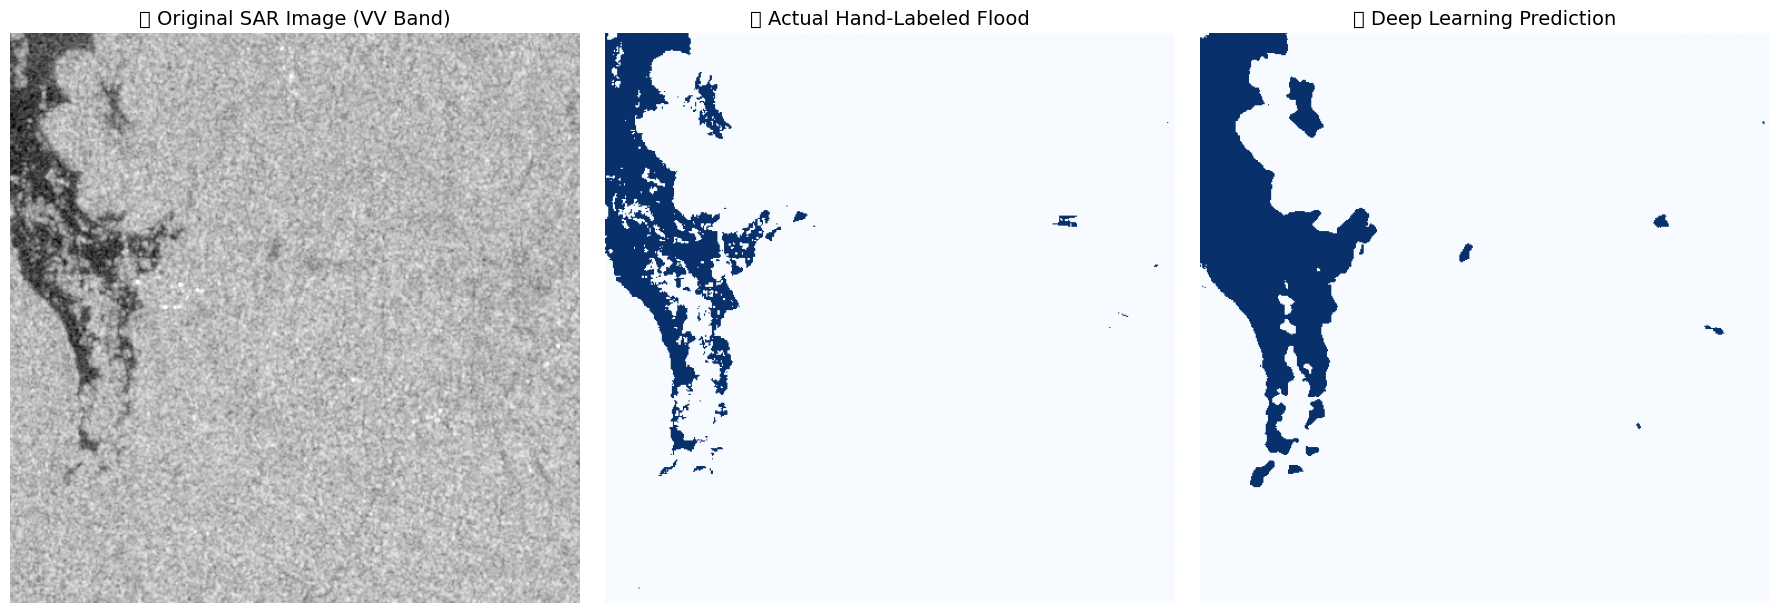

In [21]:
def visualize_prediction(model, dataset, index=0):
    model.eval()

    image, true_mask = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        raw_prediction = model(image_input)
        prob_mask = torch.sigmoid(raw_prediction)
        # Threshold at 0.5 to make a definitive "Flood" or "No Flood" prediction
        predicted_mask = (prob_mask > 0.5).float()

    # Move tensors back to CPU for plotting
    image_plot = image.cpu().numpy()
    true_mask_plot = true_mask.cpu().numpy().squeeze()
    predicted_mask_plot = predicted_mask.cpu().numpy().squeeze()

    # Create the aesthetic visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image_plot[0], cmap='gray')
    axes[0].set_title("📡 Original SAR Image (VV Band)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(true_mask_plot, cmap='Blues')
    axes[1].set_title("🗺️ Actual Hand-Labeled Flood", fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(predicted_mask_plot, cmap='Blues')
    axes[2].set_title("🤖 Deep Learning Prediction", fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize the 10th image in our dataset
visualize_prediction(model, val_dataset, index=15)


💾 Part 8: Saving Your Trained Model
Training takes time. Now that the model has learned the weights to detect floods, we need to save this state to a file (.pth). We will then trigger a download so you have a local copy to plug into your backend server.

In [11]:
from google.colab import files

# Define the file name for your saved model
model_save_path = '/content/flood_unet_resnet34.pth'

# Save only the state_dict (the learned weights), which is the PyTorch best practice
torch.save(model.state_dict(), model_save_path)
print(f"✅ Model weights saved to {model_save_path}")

# Trigger the browser to download the file to your actual computer
print("📥 Downloading model to your local machine...")
files.download(model_save_path)

✅ Model weights saved to /content/flood_unet_resnet34.pth
📥 Downloading model to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🌍 Part 9: The Dashboard Bridge (Pixels to GPS)
Your web dashboard cannot read a 2D array of pixels; it needs GeoJSON polygons (GPS coordinates) to draw the flood on a map. This function demonstrates how your future backend will take the model's prediction, read the spatial metadata from the original satellite file, and convert the flood pixels into real-world latitude and longitude boundaries.

In [23]:
import rasterio.features
from shapely.geometry import shape

def extract_flood_polygons(prediction_mask, original_tif_path):
    # 1. Open the original satellite image just to get its coordinate mapping (Transform)
    with rasterio.open(original_tif_path) as src:
        transform = src.transform
        crs = src.crs # Coordinate Reference System

    # 2. Make sure the mask is formatted properly for extraction (numpy integer array)
    mask = prediction_mask.astype('uint8')

    # 3. Extract shapes (polygons) where the mask is 1 (Flood)
    # rasterio.features.shapes returns generator of (geojson_polygon_dict, value)
    polygons = []
    for geom, value in rasterio.features.shapes(mask, transform=transform):
        if value == 1.0: # Only grab the flood zones
            # Convert to a Shapely geometry object for easy handling later
            poly = shape(geom)
            polygons.append(geom) # Storing the raw GeoJSON dict

    print(f"🗺️ Extracted {len(polygons)} distinct flooded regions as GeoJSON polygons.")
    print(f"📍 Map Coordinate System: {crs}")

    return polygons

# Let's test it on the 10th image we visualized earlier
# Let's test it on the 10th image from the validation set
sample_num = 15

# Get the original index from the full dataset
subset_index = val_dataset.indices[sample_num]

# Get the image path and true mask
test_image_path = full_dataset.image_paths[subset_index]
_, true_mask = full_dataset[subset_index]

# Extract coordinates
gps_polygons = extract_flood_polygons(
    true_mask.numpy().squeeze(),
    test_image_path
)

# Show the raw GeoJSON data for the first polygon
if gps_polygons:
    print("\nSample GeoJSON Output (Ready for your Mapbox/Leaflet frontend):")
    print(gps_polygons[0])

🗺️ Extracted 87 distinct flooded regions as GeoJSON polygons.
📍 Map Coordinate System: EPSG:4326

Sample GeoJSON Output (Ready for your Mapbox/Leaflet frontend):
{'type': 'Polygon', 'coordinates': [[(105.88478186528165, 12.183850198513069), (105.88478186528165, 12.183760366984657), (105.88487169681007, 12.183760366984657), (105.88487169681007, 12.183850198513069), (105.88478186528165, 12.183850198513069)]]}


In [25]:
import rasterio
from google.colab import files

# 1. Grab the 10th image from the dataset you already initialized in Part 4
# We know Image #10 is a good flood example from your visualization
# Use the same sample number that gave you the good prediction
sample_num = 20   # <-- change this to whatever sample worked for you

subset_index = val_dataset.indices[sample_num]
real_image_path = full_dataset.image_paths[subset_index]

print(f"✅ Extracting real professional SAR data from: {real_image_path}")

# 2. Open and save it as a clean local file
with rasterio.open(real_image_path) as src:
    data = src.read()
    meta = src.meta

# Save it to the Colab 'hard drive'
with rasterio.open('real_flood_test.tif', 'w', **meta) as dst:
    dst.write(data)

# 3. Trigger the download to your computer
print("📥 Downloading 'real_flood_test.tif' to your machine...")
files.download('real_flood_test.tif')

✅ Extracting real professional SAR data from: /content/sen1floods11/HandLabeled/S1Hand/India_166709_S1Hand.tif
📥 Downloading 'real_flood_test.tif' to your machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>